# AMAT NESTML NEST Comparision

This notebook compares the native `amat2_psc_exp` implementation with the custom NESTML `amat_neuron` model under **identical inputs and matched parameters**.

In [2]:
import nest
import pynestml
import sys
from pathlib import Path
from dataclasses import dataclass
from typing import Literal, Mapping, Sequence
import numpy as np
import matplotlib.pyplot as plt
import importlib
from pynestml.codegeneration.nest_code_generator_utils import NESTCodeGeneratorUtils


             -- N E S T --

 Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0-post0.dev14
 Built  : Jul 16 2026 16:13:29

 This program is provided AS IS and comes with NO WARRANTY.
 See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



# Build and validate the NESTML AMAT neuronal model 

In [3]:
def build_nestml_model(
    source_path: Path,
    module_name: str,) -> tuple[str, str]:
    
    if not source_path.exists():
        raise FileNotFoundError(f"NESTML source not found: {source_path}")

    generated_module, generated_model = NESTCodeGeneratorUtils.generate_code_for( # nest call to compile nestml c++ script 
        str(source_path),
        module_name=module_name,
        logging_level="INFO",)

    try:
        nest.Install(generated_module)
        print(f"Successfully installed module: '{generated_module}'")
    except nest.kernel.NESTError:
        print(f"Module '{generated_module}' is already installed. Skipping installation step.")

    # Verify the MODEL name is loaded and recognized by the NEST engine
    if generated_model not in nest.Models():
        raise RuntimeError(
            f"Generation completed, but model '{generated_model}' is missing from nest.Models()."
        )
    
    # return module, name 
    return generated_module, generated_model

# defining global variables 
nest_model = "amat2_psc_exp"
nestml_source = Path("../neurons_nestml/amat_neuron.nestml")
nestml_module = "nestml_amat_module"
resolution_ms = 0.5     # running resolution_ms test (0.5 to 0.0125) 

# calling build function
module_name, nestml_model = build_nestml_model(
    nestml_source,
    nestml_module,
)

print("Loaded module:", module_name)
print("Generated model:", nestml_model)
print("NESTML recordables:", nest.GetDefaults(nestml_model)["recordables"])

[1,GLOBAL, INFO]: List of files that will be processed:
[2,GLOBAL, INFO]: /Users/angusgray/Desktop/JSC/github/jsc_nestml_amat/juypter/scripts/../neurons_nestml/amat_neuron.nestml
[3,GLOBAL, INFO]: Target platform code will be generated in directory: "/Users/angusgray/Desktop/JSC/github/jsc_nestml_amat/juypter/scripts/target"
[4,GLOBAL, INFO]: Target platform code will be installed in directory: "/var/folders/jk/36jftn6s3yz6ks1zj2zdlry40000gn/T/nestml_target_grrh3cx8"

             -- N E S T --

 Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0-post0.dev14
 Built  : Jul 16 2026 16:13:29

 This program is provided AS IS and comes with NO WARRANTY.
 See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

[5,GLOBAL, INFO]: The NEST Simulator version was automatically detected as: main
[6,GLOBAL, INFO]: Given template root path is not an absolute path. Creating the absolute path with defa

INFO:root:Analysing input:
INFO:root:{
    "dynamics": [
        {
            "expression": "V_th_alpha_1' = (-V_th_alpha_1) / tau_1",
            "initial_values": {
                "V_th_alpha_1": "0"
            }
        },
        {
            "expression": "V_th_alpha_2' = (-V_th_alpha_2) / tau_2",
            "initial_values": {
                "V_th_alpha_2": "0"
            }
        },
        {
            "expression": "V_m' = ((-(V_m - E_L)) / tau_m + ((((unit_psc * I_kernel_exc__X__exc_spikes)) + (((-unit_psc) * I_kernel_inh__X__inh_spikes))) + I_e + I_stim) / C_m)",
            "initial_values": {
                "V_m": "E_L"
            }
        },
        {
            "expression": "V_th_v_aux' = (-V_th_v_aux) / tau_v + beta * ((-(V_m - E_L)) / tau_m + ((((unit_psc * I_kernel_exc__X__exc_spikes)) + (((-unit_psc) * I_kernel_inh__X__inh_spikes))) + I_e + I_stim) / C_m)",
            "initial_values": {
                "V_th_v_aux": "0 / 1.0"
            }
        },


[11,GLOBAL, INFO]: Starting code generation for model "amat_neuron_nestml"
[12,amat_neuron_nestml, INFO, [124:0;236:0]]: Starts processing of the model "amat_neuron_nestml"
[13,GLOBAL, INFO]: Rendering template /Users/angusgray/Desktop/JSC/github/jsc_nestml_amat/juypter/scripts/target/amat_neuron_nestml.cpp
[14,GLOBAL, INFO]: Rendering template /Users/angusgray/Desktop/JSC/github/jsc_nestml_amat/juypter/scripts/target/amat_neuron_nestml.h
[15,amat_neuron_nestml, INFO, [124:0;236:0]]: Successfully generated code for the model: "amat_neuron_nestml" in: "/Users/angusgray/Desktop/JSC/github/jsc_nestml_amat/juypter/scripts/target" !
[16,GLOBAL, INFO]: Rendering template /Users/angusgray/Desktop/JSC/github/jsc_nestml_amat/juypter/scripts/target/CMakeLists.txt
[17,GLOBAL, INFO]: Rendering template /Users/angusgray/Desktop/JSC/github/jsc_nestml_amat/juypter/scripts/target/nestml_amat_module.h
[18,GLOBAL, INFO]: Rendering template /Users/angusgray/Desktop/JSC/github/jsc_nestml_amat/juypter/scri

/Users/angusgray/Desktop/JSC/nest-simulator/mamba/lib/python3.12/site-packages/nest/lib/hl_api_helper.py:111: UserWarning:
Models is deprecated and will be removed in a future version of NEST.
Please use nest.node_models or nest.synapse_models instead!


## NEST NESTML parameter config

Building dataclass configs for NESTML and NEST models, with `Frozen=True` and `Literal[]` so the data and variables cannot be influenced and affected in downstream simulations

For instance, mismatch in NESTML, NEST:
- NESTML expects that offset directly: `omega = 5 mV`.
- Native NEST exposes `omega` as the **absolute threshold** in its status dictionary, so the equivalent value is `E_L + 5 mV = -65 mV`.


In [4]:
# restricts so only modeltype can be the following 
ModelType = Literal["nest", "nestml"]

@dataclass(frozen=True) # pass AMATConfig into both nestml and nest configs, ensures params are kept the same 
class AMATConfig:
    pulse_times_ms: tuple[float, ...] = (200.0, 220.0, 400.0, 460.0)
    pulse_amplitude_pa: float = 1000.0
    pulse_width_ms: float = 1.0
    simulation_time_ms: float = 500.0
  
    tau_m_ms: float = 10.0
    gamma: float = 1.5
    B: float = 4.0
    
    E_L_mv = -70.0
    resting_threshold_mv = -65.0
    
    alpha_1_mv: float = 10.0
    alpha_2_mv: float = 0.0

@dataclass
class SimulationResult: # 
    model_name: str
    ModelType: ModelType
    events: Mapping
    spikes: Mapping
    parameters: dict[str, float]

# Helper functions 

In [5]:
def install_generated_module(module_name: str) -> None:
    """Install the generated module if it is not already loaded.""" # ensure the generated module is in the kernel 
    try:
        nest.Install(module_name)
    except Exception as exc:
        message = str(exc).lower()
        if "loaded already" not in message and "already loaded" not in message: # should be used for nest, nestml will be built and already present. 
            raise

def create_step_current(
    pulse_times_ms: Sequence[float],
    pulse_width_ms: float,
    pulse_amplitude_pa: float,
):
    """Create a rectangular pulse train using one step-current generator."""
    amplitude_times: list[float] = []
    amplitude_values: list[float] = []

    for onset in pulse_times_ms:
        amplitude_times.extend([onset, onset + pulse_width_ms])
        amplitude_values.extend([pulse_amplitude_pa, 0.0])

    return nest.Create(
        "step_current_generator",  # input config for injecting I(e) into the neuron 
        params={
            "amplitude_times": amplitude_times,    # pulse params are stored in the public API  
            "amplitude_values": amplitude_values,    
        },
    )


def identify_model_type(model_name: str, nestml_model_name: str) -> ModelType: 
    if model_name == nest_model:
        return "nest"   # classifying what model we are running for the specified sim
    if model_name == nestml_model_name:
        return "nestml"
    raise ValueError(f"Unsupported AMAT model: {model_name}")


def build_model_parameters(
    model_name: str,
    ModelType: ModelType,
    config: AMATConfig,
) -> dict[str, float]:
    """Translate shared conceptual parameters to each model's public API."""   # public API has a frozen set of params?
    defaults = nest.GetDefaults(model_name)
    tau_m = float(defaults["tau_m"])

    return {
        "tau_m": tau_m,
        "tau_v": config.gamma * tau_m, 
        "beta": config.B / tau_m,
        "alpha_1": config.alpha_1_mv,
        "alpha_2": config.alpha_2_mv,
        "omega": config.resting_threshold_mv,
    }


# available and selected recordables may have different names dep on the nestml/nest config soruce of mismatch errors 
def select_recordables(model_name: str, requested: Sequence[str]) -> list[str]:
    """Keep only quantities actually exposed by the selected model."""
    
    available = set(nest.GetDefaults(model_name)["recordables"])   # collect the recordables available at the nest terminal 
    
    selected = [name for name in requested if name in available]
    missing = [name for name in requested if name not in available]
    
    if missing:
        print(f"{model_name}: unavailable recordables omitted: {missing}")

    return selected

In [6]:
def reconstruct_spike_kernel(times,
                             spike_times,
                             alpha, 
                             tau):
    
    # converting the inputs into NumPy arrays of decimal numbers to guarantee fast mathematical operations.
    times = np.asarray(times, dtype=float)
    spike_times = np.asarray(spike_times, dtype=float)
    result = np.zeros_like(times)

    for spike_time in spike_times:
        mask = times >= spike_time # loops through each individual spike timestamp one by one to calculate its contribution to the overall signal.
        result[mask] += (alpha * np.exp(-(times[mask] - spike_time) / tau))
        # Creates a filter of True and False values. applying the timepoint to the exact timepoint 
        
    return result 


def derive_traces(events, spikes, params, config, model_kind):
    """
    Return the same trace dictionary for native NEST and generated NESTML.

    Generated NESTML:
        alpha_1, alpha_2, theta_v, theta_v_aux are recorded directly.

    Native NEST:
        V_th is treated as relative threshold.
        alpha_1 and alpha_2 are reconstructed from output spikes.
        theta_v_aux is approximated from recorded theta_v.
    """
    times = np.asarray(events["times"])
    V_m = np.asarray(events["V_m"])
    spike_times = np.asarray(spikes["times"])

    zeros = np.zeros_like(V_m)

    omega = params["omega"]
    alpha_1 = params["alpha_1"]
    alpha_2 = params["alpha_2"]
    tau_1 = params["tau_1"]
    tau_2 = params["tau_2"]
    tau_v = params["tau_v"]
    E_L = config.E_L

    if model_kind == "nestml":
        theta_alpha_1 = np.asarray(events.get("V_th_alpha_1", zeros))
        theta_alpha_2 = np.asarray(events.get("V_th_alpha_2", zeros))
        theta_v = np.asarray(events.get("V_th_v", zeros))
        theta_v_aux = np.asarray(events.get("V_th_v_aux", zeros))

        theta_relative = omega + theta_alpha_1 + theta_alpha_2 + theta_v
        theta_absolute = E_L + theta_relative

    elif model_kind == "native":
        raw_V_th = np.asarray(events["V_th"])

        # Native NEST AMAT appears to record V_th as a relative threshold.
        theta_relative = raw_V_th
        theta_absolute = E_L + theta_relative

        theta_v = np.asarray(events.get("V_th_v", zeros))

        theta_alpha_1 = reconstruct_spike_kernel(
            times=times,
            spike_times=spike_times,
            alpha=alpha_1,
            tau=tau_1,
        )

        theta_alpha_2 = reconstruct_spike_kernel(
            times=times,
            spike_times=spike_times,
            alpha=alpha_2,
            tau=tau_2,
        )

        # Approximate the hidden auxiliary state from theta_v.
        # This is a derived diagnostic, not a true native NEST recordable.
        dt = np.mean(np.diff(times))
        dtheta_v_dt = np.gradient(theta_v, dt)
        theta_v_aux = theta_v / tau_v + dtheta_v_dt

    else:
        raise ValueError("model_kind must be 'nestml' or 'native'.")

    distance = V_m - theta_absolute

    return {
        "times": times,
        "V_m": V_m,
        "theta_absolute": theta_absolute,
        "theta_relative": theta_relative,
        "theta_alpha_1": theta_alpha_1,
        "theta_alpha_2": theta_alpha_2,
        "theta_v": theta_v,
        "theta_v_aux": theta_v_aux,
        "distance": distance,
        "spike_times": spike_times,
    }

def run_amat_model(
    model_name: str,
    nestml_model_name: str,
    module_name: str,
    config: AMATConfig,
    *,  #  When you see a bare asterisk * by itself in a function definition, it marks the end of positional arguments and the start of keyword-only arguments
    verbose: bool = True,  #  default verbose true 
) -> SimulationResult:
    """Run one AMAT implementation using the shared experiment definition."""
    
    nest.ResetKernel() # each time an AMAT mdoel is ran reset kernel, clean slate with any pre-existing param values etc. 
    nest.SetKernelStatus({"resolution": resolution_ms})
    nest.set_verbosity("M_ERROR")
    install_generated_module(module_name)

    if model_name not in nest.Models():
        raise RuntimeError(f"Model is not loaded: {model_name}")

    model_type = identify_model_type(model_name, nestml_model_name) # utilising helper functions defined in the cell above 
    parameters = build_model_parameters(model_name, model_type, config)
    neuron = nest.Create(model_name, params=parameters)

    current = create_step_current(
        config.pulse_times_ms, # calling config public times 
        config.pulse_width_ms,
        config.pulse_amplitude_pa,
    )
    nest.Connect(current, neuron)

    spike_recorder = nest.Create("spike_recorder") 
    nest.Connect(neuron, spike_recorder)

    requested_recordables = [ # request all recordables and see what's available? 
        "V_m",
        "V_th",
        "V_th_alpha_1",
        "V_th_alpha_2",
        "V_th_v",
        "V_th_v_aux",
        "I_syn_ex",
        "I_syn_in",
        "I_syn",
    ]
    recordables = select_recordables(model_name, requested_recordables)

    multimeter = nest.Create( # connect all avaialbe recordables to the multimeter 
        "multimeter",
        params={
            "interval": resolution_ms,
            "record_from": recordables,
        },
    )
    
    nest.Connect(multimeter, neuron) # connect multi meter to neuron 
    nest.Simulate(config.simulation_time_ms) # sim

    events = multimeter.get("events")
    spikes = spike_recorder.get("events")

    result_parameters = {
        **parameters,
        "gamma": config.gamma,
        "B": config.B,
        "E_L": config.E_L_mv, # result parameters for plotting and dispaly 
        "resting_threshold": config.resting_threshold_mv,
    }

    if verbose:   # In simulation scripts, it is typically a boolean flag. verbose=true, outputs whereas verbose=false quiet mode 
        print(f"\n{model_name}")
        print("Parameters sent to NEST:", parameters)
        print("Recorded variables:", recordables)
        print("Spike times:", np.asarray(spikes["times"]))
        print(
            "V_m range:",
            f"{np.min(events['V_m']):.6f} to {np.max(events['V_m']):.6f} mV",
        )

    return SimulationResult(
        model_name=model_name,
        ModelType=model_type,
        events=events,
        spikes=spikes,
        parameters=result_parameters,
    )

def get_recordables(model_kind):
    if model_kind == "native":
        return ["V_m", "V_th", "V_th_v", "I_syn_ex"]

    if model_kind == "nestml":
        return [
            "V_m",
            "V_th_alpha_1",
            "V_th_alpha_2",
            "V_th_v",
            "V_th_v_aux",
        ]

    raise ValueError("model_kind must be 'native' or 'nestml'.")


def simulate_amat(model_name, model_kind, config, module_name=None, verbose=True):
    """
    Run one AMAT simulation and return an AMATRun object.
    """
    nest.ResetKernel()
    nest.set_verbosity("M_ERROR")

    if module_name is not None:
        try:
            nest.Install(module_name)
        except Exception:
            pass

    defaults = nest.GetDefaults(model_name)

    tau_m = defaults["tau_m"]
    tau_v = config.gamma * tau_m
    beta = config.B / tau_m

    params = {
        "omega": config.omega,
        "alpha_1": config.alpha_1,
        "alpha_2": config.alpha_2,
        "beta": beta,
        "tau_v": tau_v,
        "tau_m": tau_m,
        "gamma": config.gamma,
        "B": config.B,
        "tau_1": defaults.get("tau_1", 10.0),
        "tau_2": defaults.get("tau_2", 200.0),
    }

    neuron_params = {
        "omega": params["omega"],
        "alpha_1": params["alpha_1"],
        "alpha_2": params["alpha_2"],
        "beta": params["beta"],
        "tau_v": params["tau_v"],
    }

    neuron = nest.Create(model_name, params=neuron_params)

    current = make_pulse_current(
        pulse_times=config.pulse_times,
        pulse_width=config.pulse_width,
        pulse_amplitude=config.pulse_amplitude,
    )

    nest.Connect(current, neuron)

    sr = nest.Create("spike_recorder")
    nest.Connect(neuron, sr)

    mm = nest.Create(
        "multimeter",
        params={
            "interval": 0.1,
            "record_from": get_recordables(model_kind),
        },
    )

    nest.Connect(mm, neuron)
    nest.Simulate(config.simtime)

    events = mm.get("events")
    spikes = sr.get("events")

    traces = derive_traces(
        events=events,
        spikes=spikes,
        params=params,
        config=config,
        model_kind=model_kind,
    )

    run = AMATRun(
        model_name=model_name,
        model_kind=model_kind,
        config=config,
        params=params,
        events=events,
        spikes=spikes,
        traces=traces,
    )

    if verbose:
        print(f"\n--- {model_kind.upper()} AMAT: {model_name} ---")
        print("params:", params)
        print("spikes:", spikes["times"])
        print("V_m range:", np.min(traces["V_m"]), np.max(traces["V_m"]))
        print("theta range:", np.min(traces["theta_absolute"]), np.max(traces["theta_absolute"]))
        print("distance range:", np.min(traces["distance"]), np.max(traces["distance"]))

    return run

# Mismatch in voltage recordings NEST NESTML

The native model records `V_th` as an absolute voltage. The NESTML model now records the same absolute threshold directly. Native NEST records `I_syn_ex` and `I_syn_in` separately, so total `I_syn` is their sum. Discrete differences that affect the comparision in the output 

In [7]:
def reconstruct_input_current(
    times_ms: np.ndarray,
    config: AMATConfig,
) -> np.ndarray:
    """Reconstruct the known generator command for plotting only."""
    current = np.zeros_like(times_ms, dtype=float) #  create numpty array and fill it with zeros 

    for onset in config.pulse_times_ms:
        active = (
            (times_ms >= onset) #  filling only during spike time
            & (times_ms < onset + config.pulse_width_ms)
        )
        current[active] = config.pulse_amplitude_pa  # fill current arrays with spike times 
    return current #  return the reconsturction I(e) 

def reconstruct_input_current(
    times_ms: np.ndarray,
    config: AMATConfig,
) -> np.ndarray:
    """
    Reconstruct the commanded step current for plotting.

    This is the known input supplied to the neuron, rather than a current
    recorded from the neuron itself.
    """
    times_ms = np.asarray(times_ms)
    current = np.zeros_like(times_ms, dtype=float)

    for onset in config.pulse_times_ms:
        active = (
            (times_ms >= onset)
            & (times_ms < onset + config.pulse_width_ms)
        )
        current[active] = config.pulse_amplitude_pa

    return current


def standardise_result(
    result: SimulationResult,
    config: AMATConfig,
) -> dict[str, np.ndarray]:
    """
    Convert native NEST and generated NESTML outputs into one shared format.

    Any variable that is unavailable in a model is represented by a zero
    array with the same length as V_m. This allows the plotting code to use
    the same keys for both implementations.
    """
    events = result.events

    times = np.asarray(events["times"])
    V_m = np.asarray(events["V_m"])
    zeros = np.zeros_like(V_m, dtype=float)

    # Synaptic-current names differ between implementations.
    I_syn_ex = np.asarray(events.get("I_syn_ex", zeros))
    I_syn_in = np.asarray(events.get("I_syn_in", zeros))
    I_syn = np.asarray(
        events.get("I_syn", I_syn_ex + I_syn_in)
    )

    # Threshold components exposed by the NESTML implementation.
    theta_alpha_1 = np.asarray(
        events.get("V_th_alpha_1", zeros)
    )
    theta_alpha_2 = np.asarray(
        events.get("V_th_alpha_2", zeros)
    )
    theta_v = np.asarray(
        events.get("V_th_v", zeros)
    )
    theta_v_aux = np.asarray(
        events.get("V_th_v_aux", zeros)
    )

    if "V_th" in events:
        # Native NEST exposes the total threshold directly.
        theta = np.asarray(events["V_th"])
    else:
        # Generated NESTML exposes separate threshold components.
        threshold_offset = (
            config.resting_threshold_mv - config.E_L_mv
        )

        theta = (
            config.E_L_mv
            + threshold_offset
            + theta_alpha_1
            + theta_alpha_2
            + theta_v
        )

    spike_times = np.asarray(
        result.spikes.get("times", []),
        dtype=float,
    )

    return {
        "times": times,
        "input_current": reconstruct_input_current(times, config),
        "V_m": V_m,
        "theta": theta,
        "distance": V_m - theta,
        "V_th_alpha_1": theta_alpha_1,
        "V_th_alpha_2": theta_alpha_2,
        "V_th_v": theta_v,
        "V_th_v_aux": theta_v_aux,
        "I_syn_ex": I_syn_ex,
        "I_syn_in": I_syn_in,
        "I_syn": I_syn,
        "spike_times": spike_times,
    }

# Simulate and compare NEST NESTML 

Both AMAT models now receive the same pulse times, pulse width, pulse amplitude, simulation resolution and AMAT parameters.

For checks, i've plotted error across sim_time to see if they do differ by how much? When do they differ? 

/Users/angusgray/Desktop/JSC/nest-simulator/mamba/lib/python3.12/site-packages/nest/lib/hl_api_helper.py:111: UserWarning:
Provided for backward compatibility only. Set `nest.verbosity = nest.VerbosityLevel.XYZ` instead.


amat2_psc_exp: unavailable recordables omitted: ['V_th_alpha_1', 'V_th_alpha_2', 'V_th_v_aux', 'I_syn'][INFO] [2026-07-31 09:21:52] Default for delta_tau changed from 0.1 to 0.5 ms
[INFO] [2026-07-31 09:21:52] Temporal resolution changed from 0.1 to 0.5 ms.


amat2_psc_exp
Parameters sent to NEST: {'tau_m': 10.0, 'tau_v': 15.0, 'beta': 0.4, 'alpha_1': 10.0, 'alpha_2': 0.0, 'omega': -65.0}
Recorded variables: ['V_m', 'V_th', 'V_th_v', 'I_syn_ex', 'I_syn_in']
Spike times: [462.]
V_m range: -70.000000 to -64.597928 mV

amat_neuron_nestml
Parameters sent to NEST: {'tau_m': 10.0, 'tau_v': 15.0, 'beta': 0.4, 'alpha_1': 10.0, 'alpha_2': 0.0, 'omega': -65.0}
Recorded variables: ['V_m', 'V_th', 'V_th_alpha_1', 'V_th_alpha_2', 'V_th_v', 'V_th_v_aux', 'I_syn_ex', 'I_syn_in', 'I_syn']
Spike times: [462.]
V_m range: -70.000000 to -64.597928 mV
Native NEST simulation finished.
NESTML simulation finished.
V_m          | max |Δ|=0.86464 | MAE=0.0186077 | RMSE=0.0925652
theta        | max |Δ|=1.21745 |

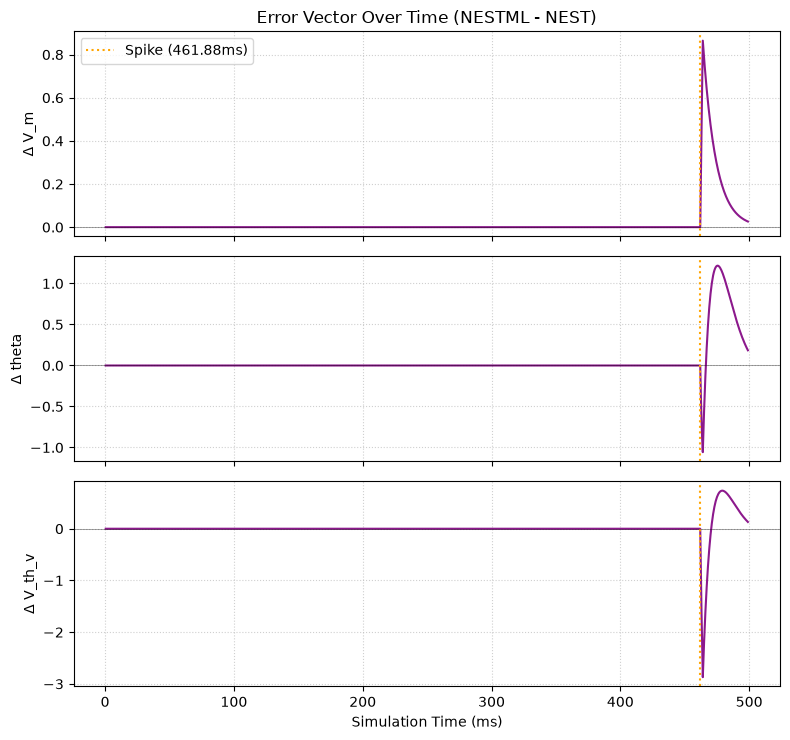

In [8]:
def compare_trace( # compare trace function, taking in two traces 
    name: str,
    left: np.ndarray,
    right: np.ndarray,
) -> dict[str, float]:
    
    if left.shape != right.shape:
        raise ValueError(
            f"{name}: incompatible shapes {left.shape} and {right.shape}" # incompabile trace to compare 
        )

    error = right - left
    metrics = {
        "max_abs_error": float(np.max(np.abs(error))),
        "mean_abs_error": float(np.mean(np.abs(error))),
        "rmse": float(np.sqrt(np.mean(error**2))),
        "error": error
    }

    print( # 6g = standard format, 12s format strings to a fixed width of 12 characters
        f"{name:12s} | "
        f"max |Δ|={metrics['max_abs_error']:.6g} | "  # maximum offset found across timepoints 
        f"MAE={metrics['mean_abs_error']:.6g} | "  # mean across the timepoints this will catch anyoffset
        f"RMSE={metrics['rmse']:.6g}" # squares every error value before averging them and taking the sqr root, penalises large deviations
    )
    return metrics

config = AMATConfig() # establish amat config 

native_result = run_amat_model(
    nest_model,
    nestml_model,
    module_name,
    config,
)

nestml_result = run_amat_model(
    nestml_model,
    nestml_model,
    module_name,
    config,
)

native = standardise_result(native_result, config)
print("Native NEST simulation finished.")
generated = standardise_result(nestml_result, config)
print("NESTML simulation finished.") 

native["V_th_alpha_1"] = reconstruct_spike_kernel(
    times=native["times"],
    spike_times=native["spike_times"],
    alpha=native_result.parameters["alpha_1"],
    tau=nest.GetDefaults(nest_model)["tau_1"],
)

native["V_th_alpha_2"] = reconstruct_spike_kernel(
    times=native["times"],
    spike_times=native["spike_times"],
    alpha=native_result.parameters["alpha_2"],
    tau=nest.GetDefaults(nest_model)["tau_2"],
)

assert np.allclose(native["times"], generated["times"])

comparison_metrics = {
    name: compare_trace(name, native[name], generated[name])
    for name in ["V_m", "theta", "V_th_v", "I_syn"]
}

print("\nSpike times")
print("Native :", np.asarray(native_result.spikes["times"]))
print("NESTML :", np.asarray(nestml_result.spikes["times"]))

# Plotting error across time (Cleaned Single-Column Layout)
times = native["times"]
variables_to_plot = ["V_m", "theta", "V_th_v"]
spike_time = 461.88

# Changed to 1 column to avoid indexing bugs
fig, axes = plt.subplots(len(variables_to_plot), 1, figsize=(8, 2.5 * len(variables_to_plot)), sharex=True)

# Handle single variable edge-case where axes isn't an array
if len(variables_to_plot) == 1:
    axes = [axes]

for i, name in enumerate(variables_to_plot):
    error_trace = comparison_metrics[name]["error"]
    
    # Plot directly onto the single column axes
    axes[i].plot(times, error_trace, color="purple", alpha=0.9)
    axes[i].set_ylabel(f"Δ {name}")
    axes[i].grid(True, linestyle=":", alpha=0.6)
    
    # Visual anchor for where error is exactly zero
    axes[i].axhline(0, color="black", linestyle="-", linewidth=0.5, alpha=0.5)
    
    # Add the spike time marker directly here
    axes[i].axvline(spike_time, color="orange", linestyle=":", linewidth=1.5, label=f"Spike ({spike_time}ms)")
    
    if i == 0: # so we are just plotting for the top trace 
        axes[i].set_title("Error Vector Over Time (NESTML - NEST)")
        axes[i].legend(loc="upper left")

# Set X-label only on the very bottom subplot
axes[-1].set_xlabel("Simulation Time (ms)")
plt.tight_layout()
plt.show()



# Overlap NEST/NESTML NEST Plot

Solid lines show native NEST; dashed lines show NESTML. The bottom row displays the direct difference `NESTML − native`.

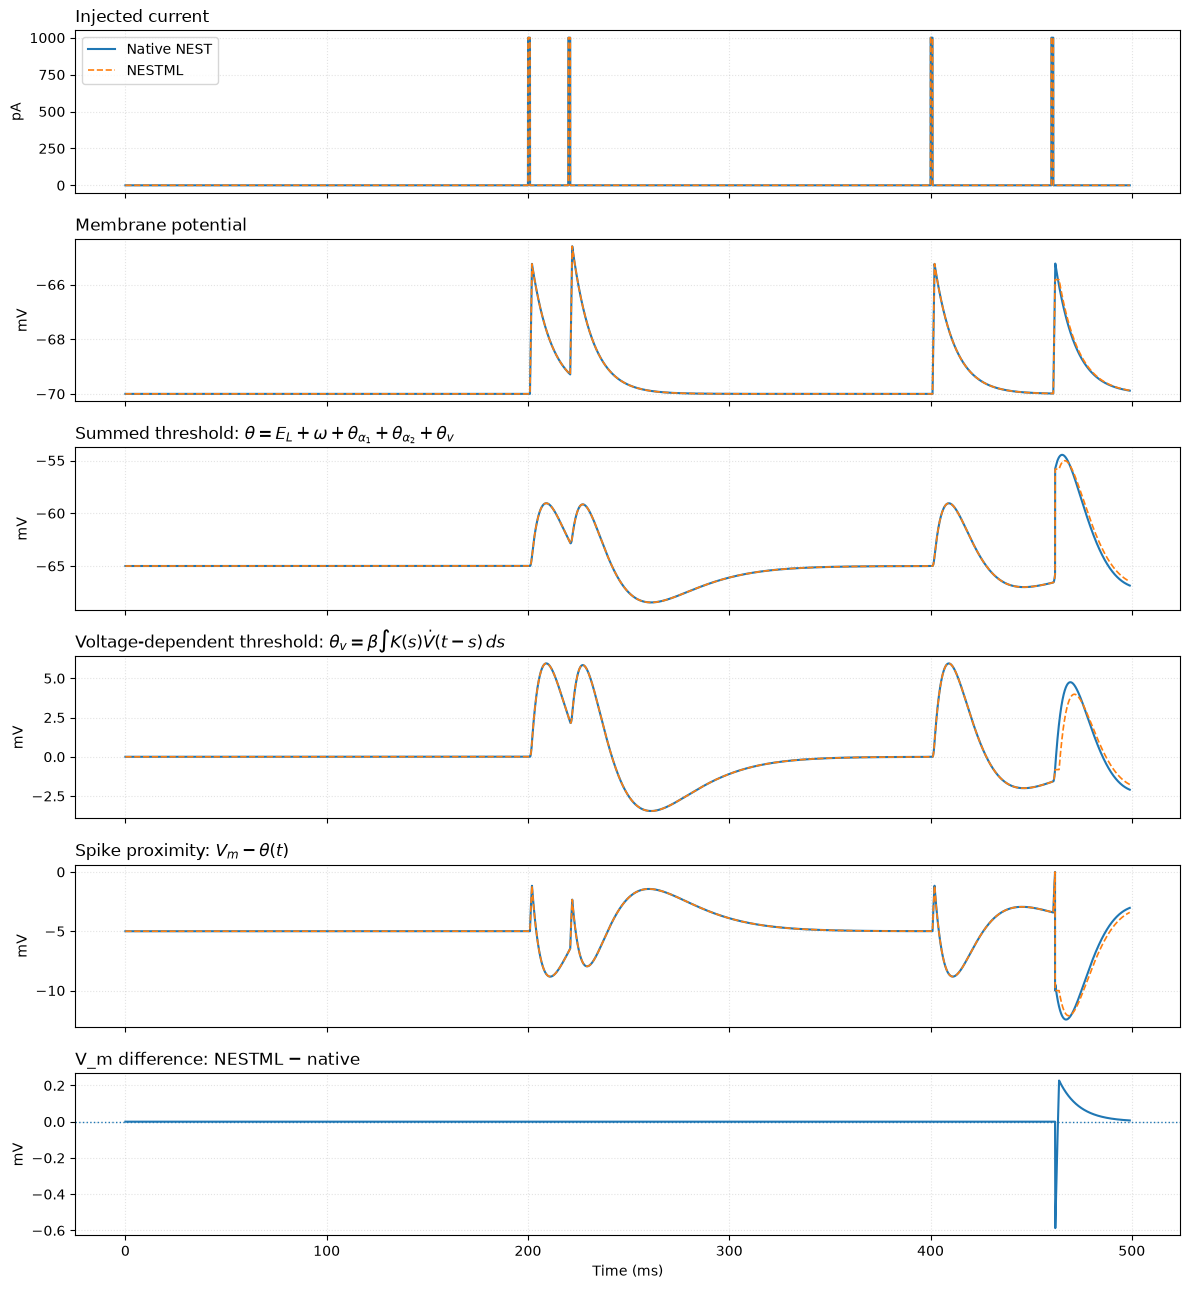

In [8]:
def plot_model_comparison_overlap(
    native: Mapping[str, np.ndarray],
    generated: Mapping[str, np.ndarray],
    *,
    xlim: tuple[float, float] | None = None,
):
    
    trace_info = [
        ("input_current", "Injected current", "pA"),  # key, title, unit
        ("V_m", "Membrane potential", "mV"),
        ("theta", r"Summed threshold: $\theta=E_L+\omega+\theta_{\alpha_1}+\theta_{\alpha_2}+\theta_v$", "mV"),
        ("V_th_v", r"Voltage-dependent threshold: $\theta_v=\beta \int K(s)\dot{V}(t-s)\,ds$", "mV"),    
        ("distance", r"Spike proximity: $V_m-\theta(t)$", "mV"),
    ]

    fig, axes = plt.subplots(
        len(trace_info) + 1,
        1,
        figsize=(12, 13),
        sharex=True,
    )

    time = native["times"]

    for ax, (key, title, unit) in zip(axes[:-1], trace_info):
        ax.plot(time, native[key], label="Native NEST", linewidth=1.5)
        ax.plot(
            time,
            generated[key],
            "--",
            label="NESTML",
            linewidth=1.2,
        )
        ax.set_ylabel(unit)
        ax.set_title(title, loc="left")
        ax.grid(True, linestyle=":", alpha=0.35)

    difference = generated["V_m"] - native["V_m"]
    axes[-1].plot(time, difference)
    axes[-1].axhline(0.0, linestyle=":", linewidth=1.0)
    axes[-1].set_title("V_m difference: NESTML − native", loc="left")
    axes[-1].set_ylabel("mV")
    axes[-1].set_xlabel("Time (ms)")
    axes[-1].grid(True, linestyle=":", alpha=0.35)

    if xlim is not None:
        axes[-1].set_xlim(*xlim)

    axes[0].legend()
    fig.tight_layout()
    return fig, axes

plot_model_comparison_overlap(native, generated)
plt.show()

# Side-by-side NESTML NEST Plot

Here we make use and display a greater variety of variables from the generated and native dataframe. 

In [ ]:
def plot_amat_side_by_side(
    native: Mapping[str, np.ndarray],
    generated: Mapping[str, np.ndarray],
    config: AMATConfig,
    *,
    native_name: str = "Native NEST",
    generated_name: str = "Generated NESTML",
    title: str | None = None,
    xlim: tuple[float, float] | None = None,
):
    """
    Plot standardised native NEST and NESTML traces side by side.

    Parameters
    ----------
    native, generated
        Dictionaries returned by standardise_result().

    config
        Shared experiment configuration. Used to mark pulse times.

    xlim
        Optional time range such as (190, 240) for a zoomed view.
    """
    rows = [
        (
            "input_current",
            "Injected current",
            "pA",
        ),
        (
            "V_m",
            r"Membrane voltage: $V_m$",
            "mV",
        ),
        (
            "theta",
            r"Total threshold: $\theta(t)$",
            "mV",
        ),
        (
            "V_th_alpha_1",
            r"Fast spike-history component: $\theta_{\alpha_1}$",
            "mV",
        ),
        (
            "V_th_alpha_2",
            r"Slow spike-history component: $\theta_{\alpha_2}$",
            "mV",
        ),
        (
            "V_th_v",
            r"Voltage-dependent component: $\theta_v$",
            "mV",
        ),
        (
            "V_th_v_aux",
            r"Auxiliary voltage-dependent state",
            "mV/ms",
        ),
        (
            "distance",
            r"Spike proximity: $V_m-\theta(t)$",
            "mV",
        ),
    ]

    runs = [
        (native, native_name),
        (generated, generated_name),
    ]

    fig, axes = plt.subplots(
        nrows=len(rows),
        ncols=2,
        figsize=(15, 2.2 * len(rows)),
        sharex="col",
        squeeze=False,
    )

    for col, (run, model_label) in enumerate(runs):
        times = np.asarray(run["times"])
        spike_times = np.asarray(
            run.get("spike_times", []),
            dtype=float,
        )

        for row, (key, label, unit) in enumerate(rows):
            ax = axes[row, col]
            values = np.asarray(run[key])

            # Defensive check: every trace must match its time vector.
            if values.shape != times.shape:
                raise ValueError(
                    f"{model_label}, {key}: "
                    f"time shape {times.shape} does not match "
                    f"trace shape {values.shape}"
                )

            ax.plot(
                times,
                values,
                linewidth=1.25,
            )

            # Mark the injected current pulse times.
            for pulse_time in config.pulse_times_ms:
                ax.axvline(
                    pulse_time,
                    linestyle="--",
                    linewidth=0.8,
                    alpha=0.35,
                )

            # Zero is meaningful for threshold components and distance.
            if key in {
                "V_th_alpha_1",
                "V_th_alpha_2",
                "V_th_v",
                "V_th_v_aux",
                "I_syn",
                "distance",
            }:
                ax.axhline(
                    0.0,
                    linestyle=":",
                    linewidth=0.9,
                    alpha=0.6,
                )

            # Show output spikes on the membrane-potential row.
            if key == "V_m":
                for spike_time in spike_times:
                    ax.axvline(
                        spike_time,
                        linewidth=1.0,
                        alpha=0.7,
                    )

            if col == 0:
                ax.set_ylabel(unit)

            if row == 0:
                ax.set_title(model_label)

            ax.text(
                0.02,
                0.92,
                label,
                transform=ax.transAxes,
                fontsize=9,
                va="top",
                ha="left",
                bbox={
                    "facecolor": "white",
                    "alpha": 0.75,
                    "edgecolor": "none",
                    "pad": 2,
                },
            )

            ax.grid(
                True,
                linestyle=":",
                alpha=0.3,
            )

            if xlim is not None:
                ax.set_xlim(*xlim)

    axes[-1, 0].set_xlabel("Time (ms)")
    axes[-1, 1].set_xlabel("Time (ms)")

    if title is not None:
        fig.suptitle(
            title,
            fontsize=14,
            y=1.002,
        )

    fig.tight_layout()
    return fig, axes


fig, axes = plot_amat_side_by_side(
    native=native,
    generated=generated,
    config=config,
    native_name=native_result.model_name,
    generated_name=nestml_result.model_name,
    title="Native NEST versus generated NESTML AMAT",
)

plt.show()